<a href="https://colab.research.google.com/github/munawirmt/EDA-Timeseries-models-in-ML/blob/main/ARIMA_%26_SARIMA_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ARIMA MODEL data prediction with airline-passengers dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.statespace.sarimax import SARIMAX
%matplotlib inline

In [38]:
from google.colab import drive
drive.mount('/content/drive')

file_path=('/content/drive/MyDrive/airline_passengers (1).csv')
df_airline=pd.read_csv(file_path)

df_airline

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0
...,...,...
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0


In [39]:
df_airline.head()

,Month,Thousands of Passengers
0,1949-01,112.0
1,1949-02,118.0
2,1949-03,132.0
3,1949-04,129.0
4,1949-05,121.0


In [40]:
df_airline.isnull().sum()

,0
Month,0
Thousands of Passengers,1


In [41]:
df_airline.tail()

,Month,Thousands of Passengers
140,1960-09,508.0
141,1960-10,461.0
142,1960-11,390.0
143,1960-12,432.0
144,International airline passengers: monthly tota...,NaN


In [42]:
df_airline.dropna(axis=0,inplace=True)

In [43]:
df_airline.isnull().sum()

,0
Month,0
Thousands of Passengers,0


In [44]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Month                    144 non-null    object 
 1   Thousands of Passengers  144 non-null    float64
dtypes: float64(1), object(1)
memory usage: 3.4+ KB


In [79]:
# Ensure 'Month' is the index and of datetime type, and set its frequency.
# This code handles cases where 'Month' might be a column or already the index.

if 'Month' in df_airline.columns:
    df_airline['Month'] = pd.to_datetime(df_airline['Month'])
    df_airline = df_airline.set_index('Month')
    df_airline.index.freq = 'MS'
elif df_airline.index.name == 'Month':
    # 'Month' is already the index, ensure its type and frequency
    if not pd.api.types.is_datetime64_any_dtype(df_airline.index):
        df_airline.index = pd.to_datetime(df_airline.index)
    df_airline.index.freq = 'MS'
else:
    raise ValueError("DataFrame is not in an expected state: 'Month' is neither a column nor the index.")

In [46]:
df_airline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Month                    144 non-null    datetime64[ns]
 1   Thousands of Passengers  144 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.4 KB


In [47]:
df_airline.head()

,Month,Thousands of Passengers
0,1949-01-01,112.0
1,1949-02-01,118.0
2,1949-03-01,132.0
3,1949-04-01,129.0
4,1949-05-01,121.0


<Axes: xlabel='Month'>

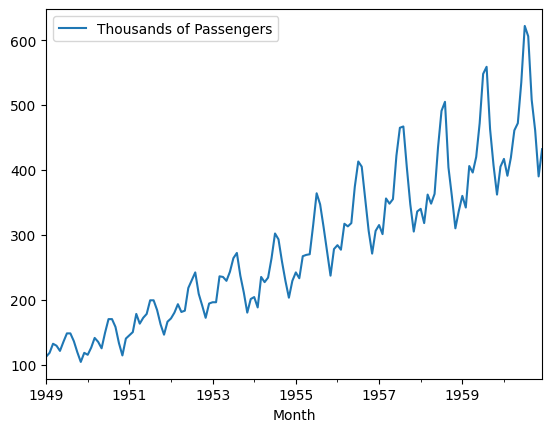

In [51]:
df_airline.plot()

In [52]:
from statsmodels.tsa.stattools import adfuller

In [53]:
def adf_test(series):
    result=adfuller(series)
    print('ADF Statistics: {}'.format(result[0]))
    print('p- value: {}'.format(result[1]))
    if result[1] <= 0.05:
        print("strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary")
    else:
        print("weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary ")

In [54]:
adf_test(df_airline['Thousands of Passengers'])

ADF Statistics: 0.8153688792060498
p- value: 0.991880243437641
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


/tmp/ipykernel_3615/4265801798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(series)


In [55]:
## Use Techniques Differencing
df_airline['Passengers First Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(1)

In [56]:
df_airline.head()

,Thousands of Passengers,Passengers First Difference
Month,,
1949-01-01,112.0,NaN
1949-02-01,118.0,6.0
1949-03-01,132.0,14.0
1949-04-01,129.0,-3.0
1949-05-01,121.0,-8.0


In [57]:
adf_test(df_airline['Passengers First Difference'].dropna())

ADF Statistics: -2.8292668241700047
p- value: 0.05421329028382478
weak evidence against null hypothesis, time series has a unit root, indicating it is non-stationary 


/tmp/ipykernel_3615/4265801798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(series)


In [58]:
## Use Techniques Differencing
df_airline['Passengers Second Difference']=df_airline['Passengers First Difference']-df_airline['Passengers First Difference'].shift(1)

In [59]:
adf_test(df_airline['Passengers Second Difference'].dropna())

ADF Statistics: -16.384231542468513
p- value: 2.7328918500142026e-29
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


/tmp/ipykernel_3615/4265801798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(series)


In [60]:
### 12 months
## Use Techniques Differencing
df_airline['Passengers 12 Difference']=df_airline['Thousands of Passengers']-df_airline['Thousands of Passengers'].shift(12)

In [61]:
adf_test(df_airline['Passengers 12 Difference'].dropna())

ADF Statistics: -3.383020726492481
p- value: 0.011551493085514952
strong evidence against the null hypothesis, reject the null hypothesis. Data has no unit root and is stationary


/tmp/ipykernel_3615/4265801798.py:2: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result=adfuller(series)


In [62]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

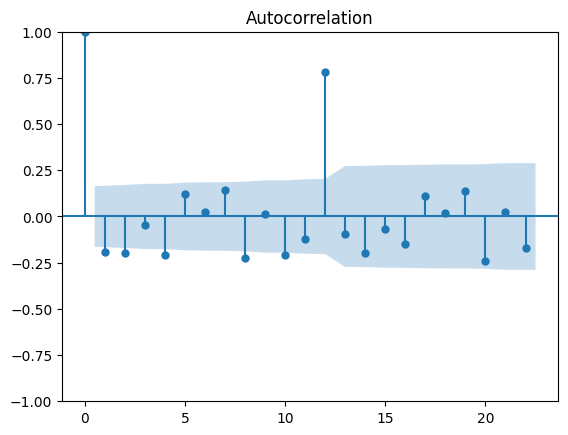

In [63]:
acf = plot_acf(df_airline["Passengers Second Difference"].dropna())

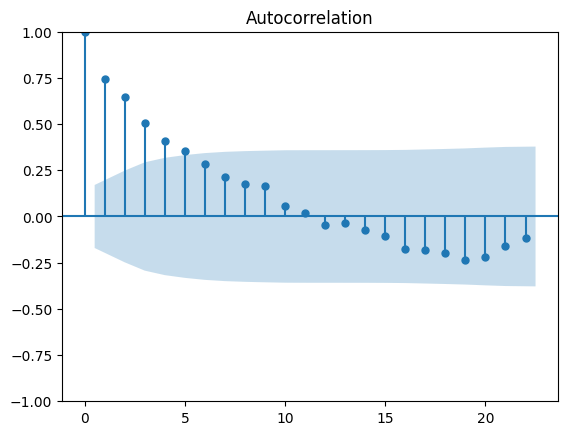

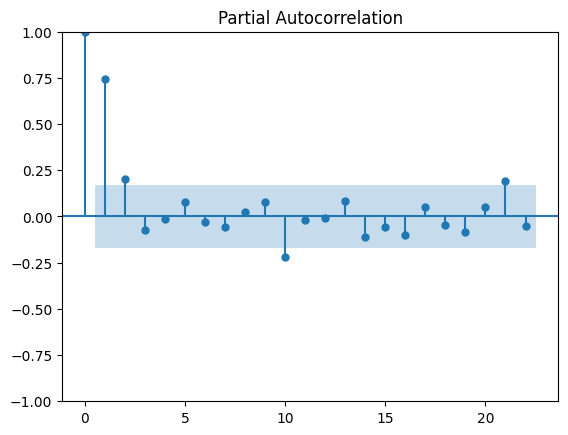

In [64]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

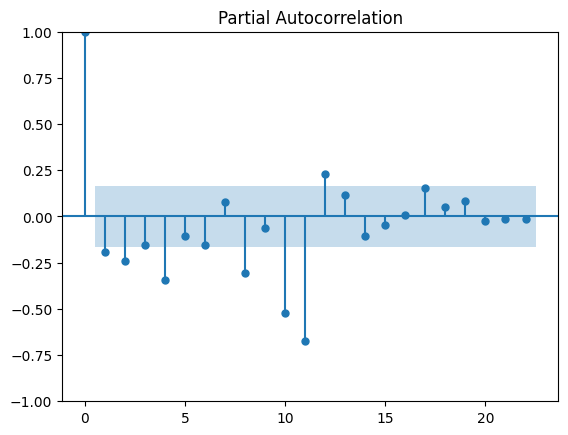

In [65]:
result = plot_pacf(df_airline["Passengers Second Difference"].dropna())

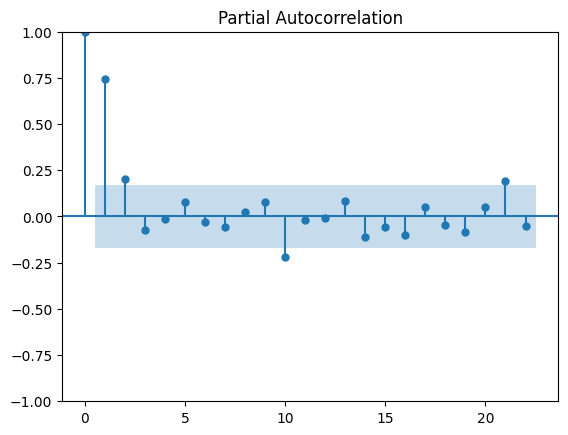

In [66]:
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

In [67]:
### split train and test data
df_airline

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1960-08-01,606.0,-16.0,-103.0,47.0
1960-09-01,508.0,-98.0,-82.0,45.0
1960-10-01,461.0,-47.0,51.0,54.0


In [68]:
from datetime import datetime,timedelta
train_dataset_end=datetime(1955,12,1)
test_dataset_end=datetime(1960,12,1)

In [80]:
train_data=df_airline[:train_dataset_end]
test_data=df_airline[train_dataset_end+timedelta(days=1):test_dataset_end]

train_data.index.freq = 'MS' # Set frequency for train_data
test_data.index.freq = 'MS'  # Set frequency for test_data

In [70]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]

In [71]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [72]:
## create a ARIMA model
from statsmodels.tsa.arima_model import ARIMA

In [73]:
train_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1949-01-01,112.0,NaN,NaN,NaN
1949-02-01,118.0,6.0,NaN,NaN
1949-03-01,132.0,14.0,8.0,NaN
1949-04-01,129.0,-3.0,-17.0,NaN
1949-05-01,121.0,-8.0,-5.0,NaN
...,...,...,...,...
1955-08-01,347.0,-17.0,-66.0,54.0
1955-09-01,312.0,-35.0,-18.0,53.0
1955-10-01,274.0,-38.0,-3.0,45.0


In [78]:
model_ARIMA = sm.tsa.SARIMAX(train_data['Thousands of Passengers'], order=(0,2,0), seasonal_order=(0,1,0,12))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [81]:
model_ARIMA_fit=model_ARIMA.fit()

In [83]:
model_ARIMA_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:            Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(0, 2, 0)x(0, 1, 0, 12)   Log Likelihood                -295.344
Date:                            Sat, 19 Sep 2026   AIC                            592.689
Time:                                    10:59:06   BIC                            594.937
Sample:                                01-01-1949   HQIC                           593.582
                                     - 12-01-1955                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2       270.5691     48.029      5.633      0.000     176.433     364.705
===================================================================================
Ljung-Box (L1) (Q):                  28.23   Jarque-Bera (JB):                 0.11
Prob(Q):                              0.00   Prob(JB):                         0.95
Heteroskedasticity (H):               1.36   Skew:                             0.03
Prob(H) (two-sided):                  0.46   Kurtosis:                         2.81
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [84]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference
Month,,,,
1956-01-01,284.0,6.0,-35.0,42.0
1956-02-01,277.0,-7.0,-13.0,44.0
1956-03-01,317.0,40.0,47.0,50.0
1956-04-01,313.0,-4.0,-44.0,44.0
1956-05-01,318.0,5.0,9.0,48.0
1956-06-01,374.0,56.0,51.0,59.0
1956-07-01,413.0,39.0,-17.0,49.0
1956-08-01,405.0,-8.0,-47.0,58.0
1956-09-01,355.0,-50.0,-42.0,43.0


In [85]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [87]:
pred=model_ARIMA_fit.predict(start=pred_start_date,end=pred_end_date)
residuals=test_data['Thousands of Passengers']-pred

In [88]:
pred

,predicted_mean
1956-01-01,306.0
1956-02-01,312.0
1956-03-01,361.0
1956-04-01,378.0
1956-05-01,394.0
1956-06-01,454.0
1956-07-01,518.0
1956-08-01,516.0
1956-09-01,496.0
1956-10-01,473.0


In [89]:
residuals

,0
Month,
1956-01-01,-22.0
1956-02-01,-35.0
1956-03-01,-44.0
1956-04-01,-65.0
1956-05-01,-76.0
1956-06-01,-80.0
1956-07-01,-105.0
1956-08-01,-111.0
1956-09-01,-141.0


<Axes: ylabel='Density'>

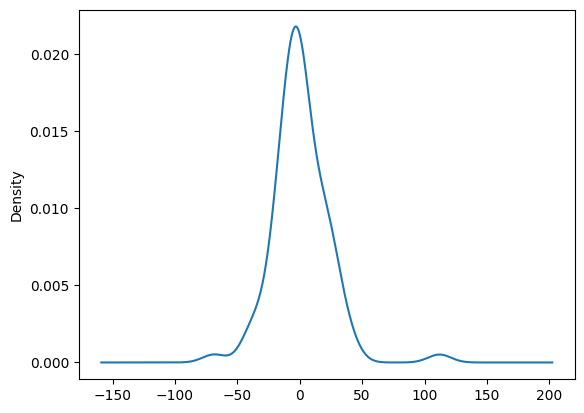

In [91]:
model_ARIMA_fit.resid.plot(kind='kde')

In [92]:
test_data['Predicted_ARIMA']=pred

/tmp/ipykernel_3615/95659616.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_ARIMA']=pred


<Axes: xlabel='Month'>

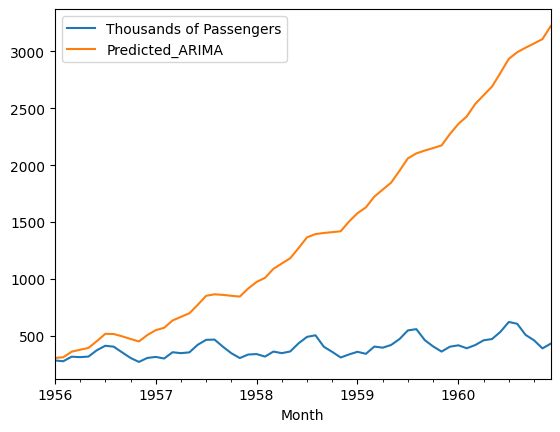

In [93]:
test_data[['Thousands of Passengers','Predicted_ARIMA']].plot()

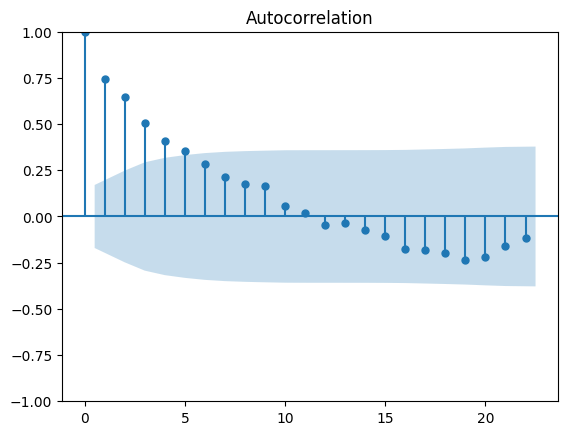

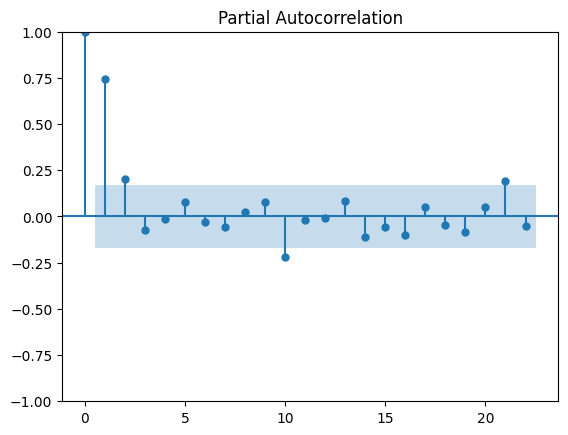

In [94]:
acf12 = plot_acf(df_airline["Passengers 12 Difference"].dropna())
pacf12 = plot_pacf(df_airline["Passengers 12 Difference"].dropna())

## SARIMA MODEL PREDICTION

In [95]:
## create a SARIMA model
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [96]:
model_SARIMA=SARIMAX(train_data['Thousands of Passengers'],order=(3,0,5),seasonal_order=(0,1,0,12))

In [97]:
model_SARIMA_fit=model_SARIMA.fit()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


In [98]:
model_SARIMA_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             Thousands of Passengers   No. Observations:                   84
Model:             SARIMAX(3, 0, 5)x(0, 1, [], 12)   Log Likelihood                -265.240
Date:                             Sat, 19 Sep 2026   AIC                            548.480
Time:                                     11:03:36   BIC                            568.970
Sample:                                 01-01-1949   HQIC                           556.638
                                      - 12-01-1955                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5974      0.937      0.637      0.524      -1.240       2.434
ar.L2          0.8310      0.232      3.584      0.000       0.377       1.285
ar.L3         -0.4516      0.893     -0.505      0.613      -2.203       1.299
ma.L1          0.1847      1.167      0.158      0.874      -2.103       2.472
ma.L2         -0.5333      1.265     -0.422      0.673      -3.012       1.945
ma.L3         -0.0988      0.385     -0.256      0.798      -0.854       0.656
ma.L4         -0.1275      0.339     -0.376      0.707      -0.792       0.537
ma.L5          0.2470      0.358      0.691      0.490      -0.454       0.948
sigma2        87.7349     81.586      1.075      0.282     -72.170     247.640
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 2.69
Prob(Q):                              0.88   Prob(JB):                         0.26
Heteroskedasticity (H):               2.05   Skew:                             0.46
Prob(H) (two-sided):                  0.09   Kurtosis:                         2.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [99]:
test_data.tail()

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA
Month,,,,,
1960-08-01,606.0,-16.0,-103.0,47.0,2992.0
1960-09-01,508.0,-98.0,-82.0,45.0,3032.0
1960-10-01,461.0,-47.0,51.0,54.0,3069.0
1960-11-01,390.0,-71.0,-24.0,28.0,3107.0
1960-12-01,432.0,42.0,113.0,27.0,3223.0


In [100]:
##prediction
pred_start_date=test_data.index[0]
pred_end_date=test_data.index[-1]
print(pred_start_date)
print(pred_end_date)

1956-01-01 00:00:00
1960-12-01 00:00:00


In [101]:
pred_Sarima=model_SARIMA_fit.predict(start=datetime(1956,6,6),end=datetime(1960,12,1))
residuals=test_data['Thousands of Passengers']-pred_Sarima

<Axes: xlabel='Month'>

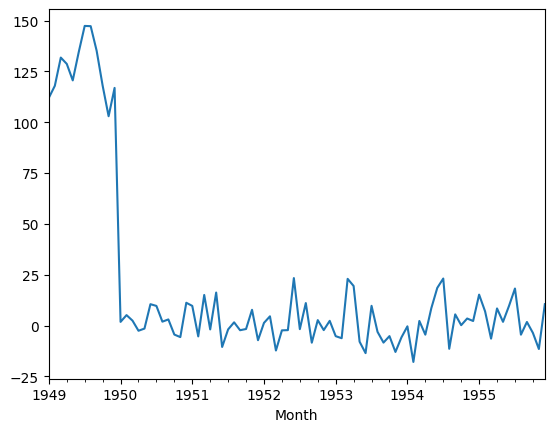

In [102]:
model_SARIMA_fit.resid.plot()

<Axes: ylabel='Density'>

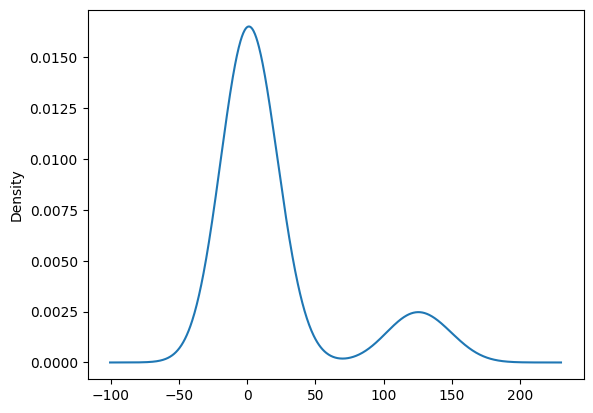

In [103]:
model_SARIMA_fit.resid.plot(kind='kde')

In [104]:
test_data['Predicted_SARIMA']=pred_Sarima

/tmp/ipykernel_3615/1367177785.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_data['Predicted_SARIMA']=pred_Sarima


In [105]:
test_data

,Thousands of Passengers,Passengers First Difference,Passengers Second Difference,Passengers 12 Difference,Predicted_ARIMA,Predicted_SARIMA
Month,,,,,,
1956-01-01,284.0,6.0,-35.0,42.0,306.0,NaN
1956-02-01,277.0,-7.0,-13.0,44.0,312.0,NaN
1956-03-01,317.0,40.0,47.0,50.0,361.0,NaN
1956-04-01,313.0,-4.0,-44.0,44.0,378.0,NaN
1956-05-01,318.0,5.0,9.0,48.0,394.0,NaN
1956-06-01,374.0,56.0,51.0,59.0,454.0,NaN
1956-07-01,413.0,39.0,-17.0,49.0,518.0,403.400398
1956-08-01,405.0,-8.0,-47.0,58.0,516.0,385.073462
1956-09-01,355.0,-50.0,-42.0,43.0,496.0,349.449217


<Axes: xlabel='Month'>

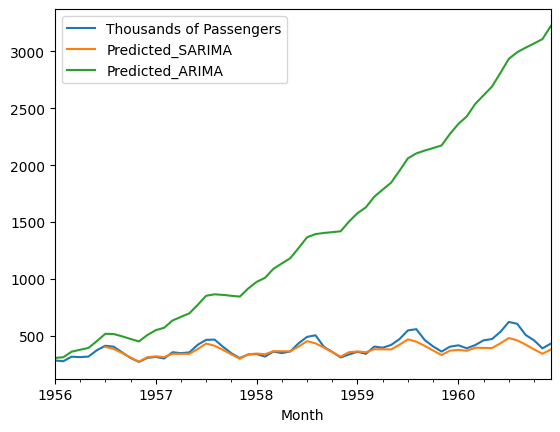

In [106]:
test_data[['Thousands of Passengers','Predicted_SARIMA','Predicted_ARIMA']].plot()